In [1]:
import pandas as pd

df = pd.read_csv("data/Advertising.csv", index_col=0)
df.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


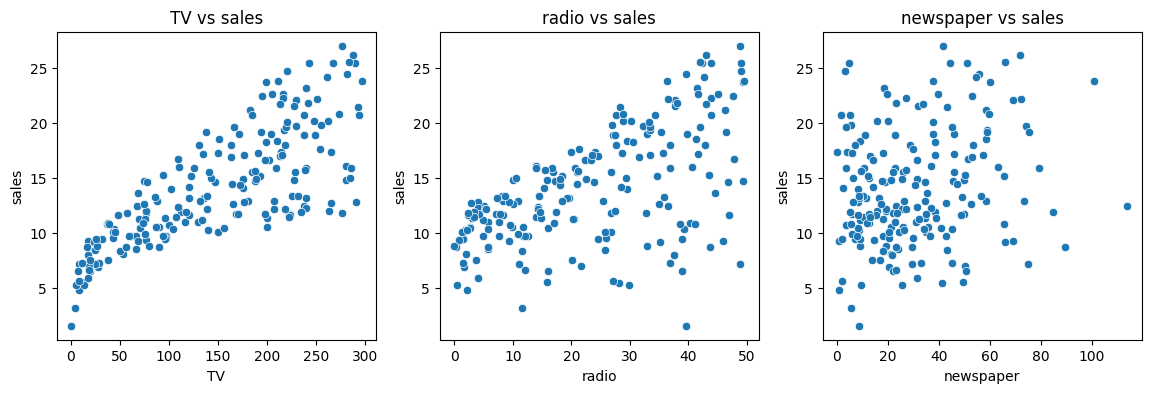

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ("TV", "radio", "newspaper")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for feature, square in zip(features, axes.flatten()):
    sns.scatterplot(data=df, x=feature, y="sales", ax=square)
    square.set(title=f"{feature} vs sales")

In [4]:
X,y = df.drop('sales', axis=1) , df['sales']

In [5]:
X.head()

,TV,radio,newspaper
1,230.1,37.8,69.2
2,44.5,39.3,45.1
3,17.2,45.9,69.3
4,151.5,41.3,58.5
5,180.8,10.8,58.4


In [6]:
y.head()

1    22.1
2    10.4
3     9.3
4    18.5
5    12.9
Name: sales, dtype: float64

# Scikit learn steps
See this as a recipe to follow, works for most classic machine learning algorithms with some modifications

steps:

1. train|test split
1. scale dataset (some algorithms don't need scaling)
1. fit algorithm with training data
1. transform training data and test data
1. evaluate on test data

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

In [8]:
print(X_test.shape)
print(X_train.shape)
print(y_test.shape)
print(y_train.shape)

(66, 3)
(134, 3)
(66,)
(134,)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

scaled_X_train.shape , scaled_X_test.shape

((134, 3), (66, 3))

In [10]:
scaled_X_train.min() , scaled_X_train.max()

(np.float64(-1.896502760070506), np.float64(3.4082087879578435))

In [11]:
scaled_X_test.min() , scaled_X_test.max()

(np.float64(-1.8393117332282525), np.float64(4.043214488303984))

## Without MLflow

In [13]:
# from sklearn.linear_model import LinearRegression, Ridge
# from sklearn.metrics import (
#     mean_absolute_error,
#     mean_squared_error,
#     r2_score,
#     root_mean_squared_error,
# )

# # 1. Put your models in a list
# models_to_test = [LinearRegression(), Ridge()]
# # Optional: Create a dictionary to save your metrics since MLflow isn't doing it anymore
# results = {}
# # 2. Loop through each model
# for model in models_to_test:
#     # 3. Grab the name of the model automatically (e.g., "Ridge")
#     model_name = type(model).__name__
#     # 4. Train the model
#     model.fit(scaled_X_test, y_test)
#     # 5. Make predictions
#     preds = model.predict(scaled_X_test)
#     # 6. Calculate scores for these specific models
#     mae = mean_absolute_error(y_test, preds)
#     mse = mean_squared_error(y_test, preds)
#     r2 = r2_score(y_test, preds)
#     rmse = root_mean_squared_error(y_test, preds)

#     # 7. Store the metrics in the dictionary
#     results[model_name] = {"MAE": mae, "MSE": mse, "R2": r2, "RMSE": rmse}
#     # 8. Print the results for each model
#     # You can now view all your results here:
# print(results)

## With MLflow

In [19]:
import mlflow
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)

# Point MLflow to your database
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Ad")
# THE MAGIC: Turn on autologging!
mlflow.sklearn.autolog()
# Put your models in a list
models_to_test = [LinearRegression(), Ridge(), Lasso(), SVR()]
# Loop through each model
for model in models_to_test:
    # 5. Grab the name of the model automatically (e.g., "Ridge")
    model_name = type(model).__name__
    # 6. Start a NEW run for EACH model in the loop!
    with mlflow.start_run(run_name=model_name):
        # 7. Autolog saves the model and params here
        model.fit(scaled_X_train, y_train)
        # 8. Make predictions
        preds = model.predict(scaled_X_test)
        # 9. Calculate scores for these specific models
        mae = mean_absolute_error(y_test, preds)
        mse = mean_squared_error(y_test, preds)
        rmse = root_mean_squared_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        # 10. Log the TEST metrics
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("MSE", mse)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)

    print(
        f"{model_name} is logged!\n MAE: {mae} MSE: {mse} RMSE: {rmse}, and R2: {r2} \n"
    )
print("You can go and check the UI !")


2026/05/22 13:57:10 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/05/22 13:57:10 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Lilit\Documents\GitHub\regression-mlflow-lab
2026/05/22 13:57:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/22 13:57:10 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Lilit\Documents\GitHub\regression-mlflow-lab
2026/05/22 13:57:10 INFO mlflow.utils.environment: Detected uv project at c:\Users\Lilit\Documents\GitHub\regression-mlflow

LinearRegression is logged!
 MAE: 1.4937750024728964 MSE: 3.727928330681507 RMSE: 1.9307843822347195, and R2: 0.8555568430680087 



2026/05/22 13:57:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/22 13:57:11 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/05/22 13:57:11 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Lilit\Documents\GitHub\regression-mlflow-lab
2026/05/22 13:57:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/22 13:57:11 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in 

Ridge is logged!
 MAE: 1.4934681526503872 MSE: 3.731015252018978 RMSE: 1.9315836124845793, and R2: 0.855437236513474 



2026/05/22 13:57:11 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/22 13:57:11 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/05/22 13:57:11 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Lilit\Documents\GitHub\regression-mlflow-lab
2026/05/22 13:57:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/22 13:57:11 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in 

Lasso is logged!
 MAE: 1.6615332281085333 MSE: 5.149382096737904 RMSE: 2.269224999143519, and R2: 0.8004808729340767 



2026/05/22 13:57:11 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


SVR is logged!
 MAE: 1.1566817674060867 MSE: 3.2094128551456524 RMSE: 1.7914834230730834, and R2: 0.8756473613293401 

You can go and check the UI !
